# RAG-Powered Telecom Customer Service Assistant

**Author:** Janhavi Ghuge

---

## Project Overview

This project builds a production-style **Retrieval-Augmented Generation (RAG)** system for a telecom company's customer service team. The system answers complex, policy-specific questions by grounding every response in a 22-document internal knowledge base — eliminating hallucinations and keeping answers consistent across agents.

### Knowledge Base Structure
The knowledge base consists of 22 Markdown files organised across four folders:
- `customer-service` — complaint handling, escalation paths, SLA compensation
- `policies` — refund rules, early termination fees, uptime guarantees
- `procedures` — step-by-step cancellation, equipment return, provisioning
- `products` — plans, pricing, bundles, add-ons

### What This Notebook Covers
1. **RAG Architecture** — how each pipeline component works in the telecom context
2. **Pipeline Development** — four progressively improved RAG versions with hyperparameter tuning
3. **System Evaluation** — six real-world test prompts ranging from medium to very hard difficulty


## Part 1: Understanding RAG Architecture

I am building a pipeline where each stage has one job and hands off to the next.

The Document Loader reads all 22 markdown files from the telecom knowledge base
and tags each one with the folder it came from (customer-service, policies,
procedures, products) as metadata.

The Text Splitter breaks each document into smaller overlapping chunks so each
piece represents one focused idea. For example one chunk might cover only the
Fiber 250 SLA uptime guarantee instead of mixing it with cancellation policies.

The Embedding Model converts every chunk into a vector of numbers that captures
its meaning. So a chunk about billing disputes and a chunk about refund timelines
will have vectors close together even if the exact words are different.

The Vector Store (ChromaDB) saves all these vectors so that when a customer
service agent asks a question, it can quickly find the chunks whose meaning is
closest to that question across all 22 documents.

The Retriever sits on top of the vector store and fetches the top k most similar
chunks for a given query.

The LLM (gpt-4-turbo) receives the agent's question plus the retrieved telecom
document chunks as context and generates an accurate answer grounded in our
actual policies and product specs rather than making things up from general
training data.

####**Understanding why would a standard LLM (without RAG) be insufficient for this task?**


The first reason is that the LLM has no knowledge of our company's specific
products, pricing, or SLA terms. For example our Fiber 250 plan has a specific
uptime guarantee and a specific credit amount for violations. The LLM has never
seen these internal documents so it would either refuse to answer or confidently
hallucinate a wrong number, which creates real legal and financial risk.

The second reason is that our documents change over time. Prices get updated,
new plans launch, and SLA thresholds get revised. The LLM has a training cutoff
and knows nothing about changes after that date. RAG solves this because we just
update the markdown files and the retriever automatically surfaces the latest
information with zero retraining.

The third reason is that our knowledge base has 22 documents across 4 categories
and a plain LLM cannot distinguish which specific procedure applies to which
situation. This is because the LLM has no awareness that these categories even
exist in our system. It was trained on general internet text so when asked about
a billing dispute it might blend together generic customer service advice from
multiple sources instead of going directly to our billing-dispute-resolution.md
file. RAG fixes this because the retriever searches the actual documents and
pulls the exact section that matches the query, so the LLM is forced to answer
from the right source.

The fourth reason is consistency. A plain LLM might answer the same question
differently each time because it is generating from probability distributions
over its training data. Two agents asking the same cancellation question could
get two different answers. RAG ensures every agent gets the answer pulled from
the same source document every single time, making responses consistent and
auditable.

###**Understanding why hyperparameter tuning matters in a RAG system.**


**Chunk Size:**
When we split documents into chunks, the size of each chunk directly affects
what the retriever finds. If chunks are too small, a question about SLA
compensation might retrieve the uptime percentage but miss the compensation
clause because it landed in a different tiny chunk that never got retrieved.
If chunks are too large, one chunk mixes five plan tiers together and the
retriever cannot tell which tier actually matches the query.

**k (number of retrieved documents):**
k controls how many chunks the retriever fetches before passing context to
the LLM. The whole point of k is to give the LLM enough relevant information
to answer the question completely. Now in our telecom knowledge base, one customer question can require information
from multiple documents at the same time. For example if a business customer
asks about an SLA violation, a complete answer needs the uptime threshold from
service-level-agreements.md AND the escalation steps from
escalation-procedures.md AND the compensation amount from a third document.
These are three separate files.

If k is set to 2, the retriever only fetches 2 chunks total. There is a very
high chance both chunks come from the same document, meaning the other two
documents never even get seen by the LLM. The agent then gets a half answer
that covers the uptime threshold but says nothing about compensation or
escalation. The customer walks away with incomplete information.

If k is set too high like 50, the LLM gets flooded with chunks from
entertainment services and international calling plans that have nothing to
do with the SLA question, which confuses the answer.

**Reranking:**
Without reranking, similarity search ranks chunks purely by how close their
embedding vectors are to the query vector. This is not the same as actual
relevance. A query about business SLA compensation might surface a home fiber
troubleshooting guide just because the word internet appears many times in both.
Cohere Rerank fixes this by reading each chunk alongside the actual query and
scoring for true relevance rather than just vector distance.

## Part 2: Building the RAG Pipeline

### Environment Setup

In [1]:
from google.colab import userdata
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')

from google.colab import drive
drive.mount('/content/drive')
import glob
import gradio as gr
from openai import OpenAI

Mounted at /content/drive


### Set Environment Variable

In [2]:
import os
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY

### Initialise Model

In [3]:
model = "gpt-4-turbo"
client = OpenAI()

### Install Requirements

In [4]:
!pip install -r requirements_new.txt -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.4/333.4 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB

### Import LangChain Dependencies

In [5]:
from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import Chroma

##Load all 22 markdown files
This loops through each subfolder (customer-service, policies, procedures, products) and tags every document with the folder name as doc_type metadata.

In [6]:
folders = glob.glob("/content/drive/MyDrive/Customer-knowledge-base/*")

documents = []
for folder in folders:
  doc_type = os.path.basename(folder)
  loader = DirectoryLoader(folder, glob="**/*.md", loader_cls=TextLoader)
  folder_docs = loader.load()
  for doc in folder_docs:
    doc.metadata["doc_type"] = doc_type
    documents.append(doc)

In [7]:
len(documents)

22

##Chunking the data using text_splitters

I am chunking the documents because a full document covers many topics at once, making it a poor match
for any specific query. Smaller chunks each represent one focused idea, so the retriever can pinpoint
the exact section that answers the question.

I chose chunk_size of 1000 because I looked at the knowledge base and noticed that most meaningful sections like one SLA tier, one refund rule, one troubleshooting procedure are roughly 800 to 1200 characters long. So 1000 felt like a reasonable starting point that would capture one complete idea without mixing two together.
The chunk_overlap of 200 makes sure nothing important gets cut off at a chunk boundary.

In [8]:
def chunk_data(data, chunk_size=1000):
  text_splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=200)
  chunk = text_splitter.split_documents(data)
  return chunk

chunks = chunk_data(documents)
print(f'this document has {len(chunks)} chunks in the data')

this document has 205 chunks in the data


##Building the Vector Store

The chunks are still raw text and computers cannot understand meaning in text
directly. OpenAIEmbeddings converts each chunk into 1536 numbers called a vector
where similar meaning chunks end up close together in space.

ChromaDB then stores
all these vectors so when a query comes in it can instantly find the most
relevant chunks by finding the closest vectors. ChromaDB is a vector database which works differently than the normal database, instead of exact matching it searches by similarity. When a query comes in it converts that query into a vector and then search which stored vectors are closest to this query vector.

In [9]:
!pip install -q chromadb

In [10]:
embeddings = OpenAIEmbeddings()
db_name = "vector_db"

if os.path.exists(db_name):
  vector_store = Chroma(persist_directory=db_name, embedding_function=embeddings)
  vector_store.delete_collection()
else:
  vector_store = Chroma(persist_directory=db_name, embedding_function=embeddings)

vector_store = Chroma.from_documents(chunks, embeddings, persist_directory=db_name)
print(f'this vector database has {vector_store._collection.count()} chunks')

sample_embedding = vector_store._collection.get(limit=1, include=['embeddings'])['embeddings'][0]
print(len(sample_embedding))

/tmp/ipykernel_3983/784347885.py:8: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vector_store = Chroma(persist_directory=db_name, embedding_function=embeddings)


this vector database has 205 chunks
1536


##Building the Retriever and Connecting it to the LLM

Now that my vectors are stored in ChromaDB I need something that can actually
go and fetch the right chunks when a question comes in. That is what the
retriever does. It takes the query, converts it into a vector, searches ChromaDB
for the closest matching chunks and returns them. I then connect it to gpt-4-turbo
through a prompt template that instructs the LLM to answer only from the retrieved
context and not from its general training data.

I am using search_type as similarity which means it ranks chunks purely by how
close their vectors are to the query vector.

I set k to 6 which means the retriever fetches the top 6 most similar chunks.
I chose 6 because our telecom questions sometimes need information from more
than one document, for example a billing question might need both the billing
dispute file and the refund policy file. Fetching only 1 or 2 chunks risks
missing that second document entirely. But fetching too many like 20 would
flood the LLM with irrelevant chunks from unrelated documents like entertainment
services or international calling plans.

I set temperature to 0 on the LLM which means it gives the most deterministic
and factual answer possible with no creativity or randomness. This is important
for a customer service system where we want consistent and accurate answers
every time not creative ones.

The prompt template instructs the LLM to answer only from the retrieved context
and not from its general training data, keeping it grounded in our actual
telecom documents.

Full flow is like
   → retriever fetches chunks from ChromaDB
   → format_docs joins chunks into text
   → prompt template wraps everything
   → LLM generates answer
   → StrOutputParser extracts clean text

In [11]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

llm = ChatOpenAI(model="gpt-4-turbo", temperature=0)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 6})

prompt = ChatPromptTemplate([
    ("system", "Answer the user query based on the context: \n\n {context}"),
    ("user", "{input}"),
    MessagesPlaceholder("chat_history")
])

def format_docs(docs):
  return "\n\n".join(doc.page_content for doc in docs)

chain = (
    {"context": retriever | format_docs, "input": RunnablePassthrough(), "chat_history": lambda x: []}
    | prompt
    | llm
    | StrOutputParser()
)

response = chain.invoke("What are the SLA uptime guarantees for business customers?")
print(response)

def chat(message, history):
  response = chain.invoke(message)
  return response

gr.ChatInterface(chat).launch()

The SLA uptime guarantees for business customers are structured as follows:

1. **Standard Business SLA**:
   - **Uptime Guarantee**: 99.7% monthly availability

2. **Premium Business SLA**:
   - **Uptime Guarantee**: 99.9% monthly availability

3. **Enterprise SLA**:
   - **Uptime Guarantee**: 99.95% monthly availability

4. **Mission Critical SLA**:
   - **Uptime Guarantee**: 99.99% monthly availability

These guarantees reflect the commitment to maintaining service availability at different levels based on the tier of service purchased by the business customer.


/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f64ee3d4cadc232364.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Version 2a — Reranking (Hyperparameter Tuning #1)

### Hyperparameter Tuning 1 - Reranking the similarity search

The basic retriever I built works but it has one weakness. It ranks chunks purely
by vector distance which is not the same as actual relevance. For example a query
about business SLA compensation might surface a home fiber troubleshooting chunk
just because the word internet appears many times in both.

To fix this I am adding CohereRerank. The idea is to first cast a wide net by
fetching 20 chunks instead of 6, then let Cohere read each chunk alongside the
actual query and score them for true relevance. Only the top 5 most relevant
chunks survive and get passed to the LLM.

I set k to 20 because we want a large candidate pool for Cohere to work with.
If we only gave Cohere 6 chunks the truly relevant ones might not even be in
that pool. I set top_n to 5 because after reranking we only want the best ones
going to the LLM, too many would add noise.

In [12]:
!pip install langchain-cohere -q

In [13]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_cohere import CohereRerank

os.environ["CO_API_KEY"] = userdata.get('CO_API_KEY')

llm = ChatOpenAI(model="gpt-4-turbo", temperature=0)
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k': 20})
reranker = CohereRerank(model="rerank-english-v3.0", top_n=5)

def retrieve_and_rerank(query):
  docs = retriever.invoke(query)
  return reranker.compress_documents(docs, query)

prompt = ChatPromptTemplate([
    ("system", "Answer the user query using the context provided: \n\n {context}"),
    ("user", "{input}"),
    MessagesPlaceholder("chat_history")
])

def format_docs(docs):
  return "\n\n".join(doc.page_content for doc in docs)

chain = (
    {"context": RunnableLambda(retrieve_and_rerank) | format_docs, "input": RunnablePassthrough(), "chat_history": lambda x: []}
    |prompt
    |llm
    |StrOutputParser()
)

response = chain.invoke("What are the SLA uptime guarantees for business customers?")
print(response)

def chat(message, history):
  response = chain.invoke(message)
  return response

gr.ChatInterface(chat).launch()

The SLA uptime guarantees for business customers are structured as follows:

1. **Standard Business SLA**:
   - **Uptime Guarantee**: 99.7% monthly availability

2. **Premium Business SLA**:
   - **Uptime Guarantee**: 99.9% monthly availability

3. **Enterprise SLA**:
   - **Uptime Guarantee**: 99.95% monthly availability

4. **Mission Critical SLA**:
   - **Uptime Guarantee**: 99.99% monthly availability

These guarantees reflect the commitment to maintaining service availability at different levels based on the tier of service purchased by the business customer.


/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d2a46094881a7aa60e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Version 2b — Query Expansion + Reranking (Hyperparameter Tuning #2)

The reranking I added works well but there is still one problem. The retriever
only searches using the exact words the user typed. If the user asks "cancel
contract" but our document says "early termination fee" the retriever might
completely miss that document because the words do not match even though the
meaning is identical.

Query expansion fixes this by asking the LLM to rephrase the original query 3
different ways before searching. So instead of searching once we search 4 times
with 4 different phrasings, combine all the results, remove duplicates and then
rerank the entire combined pool. This way vocabulary mismatches between how the
agent asks and how the document is written no longer cause relevant chunks to
be missed.

I set k to 10 per query because we are now running 4 searches so the total
candidate pool before deduplication could be up to 40 chunks which is already
a large enough pool for Cohere to rerank from.

In [14]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_cohere import CohereRerank

os.environ["CO_API_KEY"] = userdata.get('CO_API_KEY')

llm = ChatOpenAI(model="gpt-4-turbo", temperature=0)
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k': 10})
reranker = CohereRerank(model="rerank-english-v3.0", top_n=5)

def expand_query(query):
    """Use LLM to generate 3 query variations"""
    expansion_prompt = f"""Generate 3 different versions of this search query to get better search results.
Return only the 3 queries, one per line, no numbering.

Original query: {query}"""

    expandresponse = llm.invoke(expansion_prompt)
    queries = [q.strip() for q in expandresponse.content.strip().split('\n') if q.strip()]
    return [query] + queries[:3]  # Original + up to 3 expansions

def retrieve_with_expansion_and_rerank(query):
    # Expand query into multiple versions
    queries = expand_query(query)

    # Retrieve for each query and dedup ensures unique documents only
    all_docs = []
    seen = set()
    for q in queries:
        docs = retriever.invoke(q)
        for doc in docs:
            if doc.page_content not in seen:
                seen.add(doc.page_content)
                all_docs.append(doc)

    # Rerank all combined docs against original query
    return reranker.compress_documents(all_docs, query)

prompt = ChatPromptTemplate([
    ("system", "Answer the user query using the context provided: \n\n {context}"),
    ("user", "{input}"),
    MessagesPlaceholder("chat_history")
])

def format_docs(docs):
  return "\n\n".join(doc.page_content for doc in docs)

chain = (
    {"context": RunnableLambda(retrieve_with_expansion_and_rerank) | format_docs, "input": RunnablePassthrough(), "chat_history": lambda x: []}
    |prompt
    |llm
    |StrOutputParser()
)

response = chain.invoke("What are the SLA uptime guarantees for business customers?")
print(response)

def chat(message, history):
  response = chain.invoke(message)
  return response

gr.ChatInterface(chat).launch()

The SLA uptime guarantees for business customers are structured as follows:

1. **Standard Business SLA**:
   - **Uptime Guarantee**: 99.7% monthly availability

2. **Premium Business SLA**:
   - **Uptime Guarantee**: 99.9% monthly availability

3. **Enterprise SLA**:
   - **Uptime Guarantee**: 99.95% monthly availability

4. **Mission Critical SLA**:
   - **Uptime Guarantee**: 99.99% monthly availability

These guarantees reflect the commitment to maintaining service availability at different levels based on the tier of service purchased by the business customer.


/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2013c662617d24aade.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Version 2c — Parent-Child Chunking + Query Expansion + Reranking (Hyperparameter Tuning #3)

### Hyperparameter Tuning 3 - Parent Child Chunking

So far I have been searching and passing the same 1000 character chunks to the
LLM. This creates a tension. Small chunks are good for retrieval because they
represent one focused idea and match queries precisely. But small chunks are bad
for the LLM because they lack surrounding context. For example a 1000 character
chunk might contain the SLA compensation amount but cut off before explaining
the conditions under which it applies.

Parent child chunking solves this tension by having two levels of chunks. Child
chunks are small at 400 characters and are what gets embedded and searched.
Parent chunks are large at 2000 characters and are what gets passed to the LLM.
I keep a dictionary called child_to_parent that maps every child back to the
parent it came from.

So during retrieval the child chunk finds the exact right section with precision.
But before passing to the LLM I swap each child for its parent so the LLM gets
the full surrounding context. The child finds the right page, the parent gives
the LLM the whole chapter.

I set child chunk size to 400 because it is small enough to represent one
specific idea for precise matching. I set parent chunk size to 2000 because it
is large enough to contain the full context around that idea without mixing too
many unrelated topics together.

In [15]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_cohere import CohereRerank

os.environ["CO_API_KEY"] = userdata.get('CO_API_KEY')

# ============================================================
# STEP 1: PARENT-CHILD CHUNKING (replaces original chunking)
# ============================================================

# PARENT = Large chunks (2000 chars) - what LLM will see
parent_splitter = RecursiveCharacterTextSplitter(chunk_size=2000, chunk_overlap=200)
parents = parent_splitter.split_documents(documents)

# CHILD = Small chunks (400 chars) - what we search on
child_splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=50)

# Link each child to its parent
children = []
child_to_parent = {}

for parent in parents:
    parent_children = child_splitter.split_documents([parent])
    for child in parent_children:
        children.append(child)
        child_to_parent[child.page_content] = parent

# Build vector store on CHILDREN
embeddings = OpenAIEmbeddings()
vector_store = Chroma.from_documents(children, embeddings)

#Step 2....

llm = ChatOpenAI(model="gpt-4-turbo", temperature=0)
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k': 10})
reranker = CohereRerank(model="rerank-english-v3.0", top_n=5)

def expand_query(query):
    """Use LLM to generate 3 query variations"""
    expansion_prompt = f"""Generate 3 different versions of this search query to get better search results.
Return only the 3 queries, one per line, no numbering.

Original query: {query}"""

    expandresponse = llm.invoke(expansion_prompt)
    queries = [q.strip() for q in expandresponse.content.strip().split('\n') if q.strip()]
    return [query] + queries[:3]

def retrieve_with_expansion_and_rerank(query):
    # Expand query into multiple versions
    queries = expand_query(query)

    # Retrieve CHILDREN for each query
    all_children = []
    seen = set()
    for q in queries:
        docs = retriever.invoke(q)
        for doc in docs:
            if doc.page_content not in seen:
                seen.add(doc.page_content)
                all_children.append(doc)

    # Rerank children chunks
    reranked_children = reranker.compress_documents(all_children, query)

    # Swap children for PARENTS (more context for LLM)
    parents_out = []
    seen_parents = set()
    for child in reranked_children:
        parent = child_to_parent.get(child.page_content, child)
        if parent.page_content not in seen_parents:
            seen_parents.add(parent.page_content)
            parents_out.append(parent)

    return parents_out

prompt = ChatPromptTemplate([
    ("system", "Answer the user query using the context provided: \n\n {context}"),
    ("user", "{input}"),
    MessagesPlaceholder("chat_history")
])

def format_docs(docs):
  return "\n\n".join(doc.page_content for doc in docs)

chain = (
    {"context": RunnableLambda(retrieve_with_expansion_and_rerank) | format_docs, "input": RunnablePassthrough(), "chat_history": lambda x: []}
    |prompt
    |llm
    |StrOutputParser()
)

response = chain.invoke("What are the SLA uptime guarantees for business customers?")
print(response)

def chat(message, history):
  response = chain.invoke(message)
  return response

gr.ChatInterface(chat).launch()

The SLA uptime guarantees for business customers are structured into different tiers, each designed to meet varying levels of business needs:

1. **Standard Business SLA**: 99.7% monthly availability
2. **Premium Business SLA**: 99.9% monthly availability
3. **Enterprise SLA**: 99.95% monthly availability
4. **Mission Critical SLA**: 99.99% monthly availability

Each tier offers a higher level of uptime guarantee to accommodate the criticality and operational demands of different types of businesses.


/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://29f923cf9541c65f47.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Version 2d — Metadata Filtering + All Previous Strategies (Hyperparameter Tuning #4)

### Hyperparameter Tuning 4 - Metadata Filtering

Even with everything I have built so far, ChromaDB still searches across all 22
documents for every single query. That means a question about a billing dispute
has to compete against chunks from entertainment services, international calling
plans and mobile packages before reranking can clean things up. This adds
unnecessary noise to the candidate pool.

Metadata filtering solves this by narrowing the search space before similarity
search even starts. Remember when I loaded the documents I tagged every chunk
with the folder it came from as doc_type. Now I use that tag to restrict
ChromaDB to only search inside the relevant folders.

I added a detect_filters function that sends the query to the LLM and asks it
to classify which of our four categories are relevant. I am only filtering by doc_type and not by year or source because those fields
were never stored as metadata during loading, so ChromaDB has nothing to filter
on for them. For example a question
about an SLA violation would be classified as policies and procedures. ChromaDB
then completely skips the products and customer-service folders. The candidate
pool going into reranking is already cleaner and more focused from the start
which leads to better final answers.

The complete pipeline for every query is now: detect relevant categories, filter
ChromaDB to those categories, expand the query into 4 versions, retrieve child
chunks, rerank, swap to parents, LLM generates the answer.

In [16]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_cohere import CohereRerank

os.environ["CO_API_KEY"] = userdata.get('CO_API_KEY')

# ============================================================
# STEP 1: PARENT-CHILD CHUNKING (replaces original chunking)
# ============================================================

# PARENT = Large chunks (2000 chars) - what LLM will see
parent_splitter = RecursiveCharacterTextSplitter(chunk_size=2000, chunk_overlap=200)
parents = parent_splitter.split_documents(documents)

# CHILD = Small chunks (400 chars) - what we search on
child_splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=50)

# Link each child to its parent
children = []
child_to_parent = {}

for parent in parents:
    parent_children = child_splitter.split_documents([parent])
    for child in parent_children:
        children.append(child)
        child_to_parent[child.page_content] = parent

# Build vector store on CHILDREN
embeddings = OpenAIEmbeddings()
vector_store = Chroma.from_documents(children, embeddings)

#Step 2....

llm = ChatOpenAI(model="gpt-4-turbo", temperature=0)
reranker = CohereRerank(model="rerank-english-v3.0", top_n=5)

def detect_filters(query):
    """Use LLM to classify which doc_type category the query belongs to"""
    filter_prompt = f"""You are classifying a telecom customer service query into document categories.
The available categories are exactly:
- customer-service
- policies
- procedures
- products

Query: {query}

List only the relevant category names from the four above, one per line.
Use "none" if no specific category applies."""

    response = llm.invoke(filter_prompt)
    content = response.content.strip().lower()

    valid = {"customer-service", "policies", "procedures", "products"}
    categories = [line.strip() for line in content.split('\n') if line.strip() in valid]
    return categories

def expand_query(query):
    """Use LLM to generate 3 query variations"""
    expansion_prompt = f"""Generate 3 different versions of this search query to get better search results.
Return only the 3 queries, one per line, no numbering.

Original query: {query}"""

    expandresponse = llm.invoke(expansion_prompt)
    queries = [q.strip() for q in expandresponse.content.strip().split('\n') if q.strip()]
    return [query] + queries[:3]

def retrieve_with_expansion_and_rerank(query):
    # Detect which categories are relevant
    categories = detect_filters(query)
    print(f"Detected categories: {categories}")

    # Build retriever with metadata filter
    if categories:
        if len(categories) == 1:
            filter_dict = {"doc_type": categories[0]}
        else:
            filter_dict = {"$or": [{"doc_type": cat} for cat in categories]}
        retriever = vector_store.as_retriever(
            search_kwargs={'k': 10, 'filter': filter_dict}
        )
    else:
        retriever = vector_store.as_retriever(search_kwargs={'k': 10})

    # Expand query into multiple versions
    queries = expand_query(query)

    # Retrieve CHILDREN for each query
    all_children = []
    seen = set()
    for q in queries:
        docs = retriever.invoke(q)
        for doc in docs:
            if doc.page_content not in seen:
                seen.add(doc.page_content)
                all_children.append(doc)

    # Rerank children chunks
    reranked_children = reranker.compress_documents(all_children, query)

    # Swap children for PARENTS (more context for LLM)
    parents_out = []
    seen_parents = set()
    for child in reranked_children:
        parent = child_to_parent.get(child.page_content, child)
        if parent.page_content not in seen_parents:
            seen_parents.add(parent.page_content)
            parents_out.append(parent)

    return parents_out

prompt = ChatPromptTemplate([
    ("system", "Answer the user query using the context provided: \n\n {context}"),
    ("user", "{input}"),
    MessagesPlaceholder("chat_history")
])

def format_docs(docs):
  return "\n\n".join(doc.page_content for doc in docs)

chain = (
    {"context": RunnableLambda(retrieve_with_expansion_and_rerank) | format_docs, "input": RunnablePassthrough(), "chat_history": lambda x: []}
    |prompt
    |llm
    |StrOutputParser()
)

response = chain.invoke("What are the SLA uptime guarantees for business customers?")
print(response)

def chat(message, history):
  response = chain.invoke(message)
  return response

gr.ChatInterface(chat).launch()

Detected categories: ['policies']
The SLA uptime guarantees for business customers vary depending on the tier of service they subscribe to. Here are the details:

1. **Standard Business SLA:**
   - **Uptime Guarantee**: 99.7% monthly availability

2. **Premium Business SLA:**
   - **Uptime Guarantee**: 99.9% monthly availability

3. **Enterprise SLA:**
   - **Uptime Guarantee**: 99.95% monthly availability

4. **Mission Critical SLA:**
   - **Uptime Guarantee**: 99.99% monthly availability

These guarantees reflect the percentage of time the service is expected to be operational each month, with higher tiers offering greater reliability to meet the needs of more critical business operations.


/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://40275249f94700b9c8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Part 3: Evaluating the System

**All six test prompts below are run against the final pipeline (Version 2d). Each prompt is followed by a screenshot of the Gradio output and a written evaluation covering metadata filter accuracy, response quality, and system limitations.**

In [17]:
prompt_1 = """A residential customer on the Fiber 250 package reports that their
speed test shows only 150 Mbps during peak evening hours. They want to know if
this is within the acceptable range according to the service level agreement,
and what steps they should take if it is not."""

response_1 = chain.invoke(prompt_1)
print(response_1)

Detected categories: ['customer-service', 'policies']
Based on the service level agreement (SLA) for the Fiber 250 package, the expected performance standards are as follows:

- **Peak Performance**: 95% of advertised speed during optimal conditions, which would be around 237.5 Mbps.
- **Standard Performance**: 80% of advertised speed during peak hours (7-11 PM), which would be 200 Mbps.

Since the customer is experiencing speeds of 150 Mbps during peak hours, this is below the minimum standard performance of 200 Mbps as per the SLA for the Fiber 250 package.

### Steps to Take:

1. **Verify Speeds**:
   - Conduct multiple speed tests using Omantel's certified speed testing platform (speedtest.omantel.com) to ensure accuracy.
   - Perform tests at different times to confirm if the issue persists outside of peak hours.

2. **Router and Equipment Check**:
   - Restart the router by unplugging it for about 30 seconds and then plugging it back in.
   - Ensure that the router is not placed 

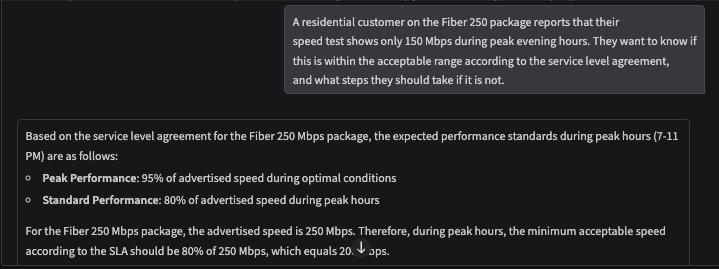


The metadata filter correctly identified customer-service and policies as the
relevant categories which are exactly the right folders for this question.

The response was accurate and well grounded. It correctly pulled the 80%
standard performance threshold from the SLA, calculated that 200 Mbps is the
minimum acceptable speed for Fiber 250, and correctly identified that 150 Mbps
falls below that threshold.

The escalation steps were specific and pulled directly from the knowledge base
including actual contact numbers for different regions which shows the RAG
retrieved the right chunks from the customer-service folder.

One thing that could be improved is that the response did not mention what
specific service credit or compensation the customer is entitled to if the issue
is not resolved which is information that likely exists in the policies folder.
This shows a limitation where even with the right categories detected, the top 5
reranked chunks may not always cover every aspect of a complex question.

In [18]:
prompt_2 = """What are all the available individual postpaid mobile plans? Compare
the data allowances, international calling minutes, and any bundled entertainment
services across these plans. Which plan would you recommend for a heavy data user
who streams video daily?"""

response_2 = chain.invoke(prompt_2)
print(response_2)

Detected categories: ['products']
Here's a comparison of the individual postpaid mobile plans available, focusing on data allowances, international calling minutes, and bundled entertainment services:

1. **Freedom 20 Plan**
   - **Data**: 15 GB high-speed data
   - **International**: No international minutes included
   - **Entertainment**: None specified

2. **Freedom 35 Plan**
   - **Data**: 30 GB high-speed data
   - **International**: 50 minutes to 15 countries
   - **Entertainment**: None specified

3. **Freedom 50 Plan**
   - **Data**: 50 GB high-speed data
   - **International**: 100 minutes to 25 countries
   - **Entertainment**: Netflix Premium + Spotify Premium

4. **Freedom Unlimited**
   - **Data**: Unlimited high-speed data (fair usage: 200 GB)
   - **International**: 200 minutes to 50+ countries
   - **Entertainment**: None specified directly, but extensive data allows for significant streaming.

### Recommendation for a Heavy Data User Who Streams Video Daily

For a hea

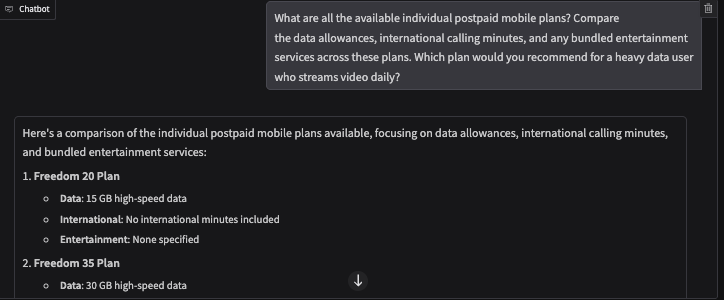

The metadata filter correctly identified products as the only relevant category
which makes sense since this question is entirely about mobile plan specifications.

The response was accurate and complete. It successfully retrieved all four
individual postpaid plans, correctly listed the data allowances, international
calling minutes and bundled entertainment services for each one and presented
them in a clean comparable format.

The recommendation was well reasoned. It correctly identified Freedom 50 and
Freedom Unlimited as the top two options for a heavy data user and gave a
nuanced explanation of when to choose one over the other depending on whether
the user prioritizes entertainment bundles or raw data volume.

This prompt performed the better than the first one  because it maps cleanly to one
folder and one document. The metadata filter eliminated all noise from other
categories and the reranker had a very focused pool to work with which resulted
in a precise and complete answer.

In [19]:
prompt_3 = """A business customer with a Premium SLA has experienced two service
outages this month - one lasting 3 hours and another lasting 1.5 hours. They
want to know: (1) whether each outage violated their SLA uptime guarantee,
(2) what compensation or credits they are entitled to for each incident,
(3) the correct escalation path if they are unsatisfied with the resolution,
and (4) what proactive monitoring commitments the provider should deliver
going forward."""

response_3 = chain.invoke(prompt_3)
print(response_3)

Detected categories: ['policies', 'procedures']
For a business customer with a Premium SLA, here's a detailed response to each of your queries:

1. **SLA Uptime Guarantee Violation:**
   - The Premium SLA promises a 99.9% monthly availability. To determine if the outages violated the SLA, we need to calculate the total downtime and compare it to the allowed downtime under the SLA.
   - Monthly allowed downtime for 99.9% availability in a 30-day month is approximately 43.2 minutes (0.1% of 43200 minutes in 30 days).
   - The total reported downtime (3 hours + 1.5 hours = 4.5 hours or 270 minutes) significantly exceeds the allowed 43.2 minutes. Therefore, both outages violate the Premium SLA uptime guarantee.

2. **Compensation or Credits:**
   - For the Premium SLA, the monthly credit for SLA violations is 10% of the service charges. Since the SLA was violated, the customer is entitled to this credit.
   - Additionally, if the total downtime significantly impacts business operations, th

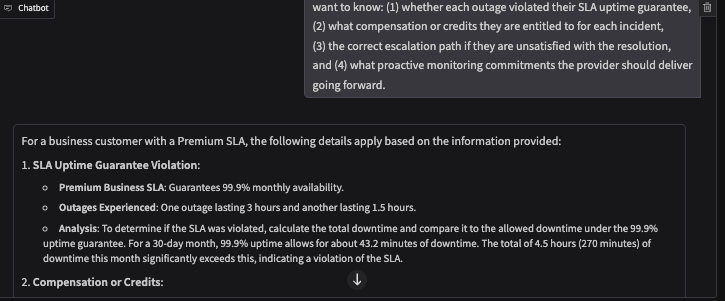

The metadata filter correctly detected all three relevant categories which are
customer-service, policies and procedures. This is exactly right since this
question spans all three folders.

The response was impressive and covered all four sub questions completely. For
sub question 1 it correctly identified the 99.9% uptime guarantee for Premium
Business SLA, calculated the allowed downtime as 43.2 minutes and correctly
concluded that 270 minutes of total downtime is a clear violation.

For sub question 2 it correctly retrieved the 10% service credit compensation
and explained how it would be applied to the next billing cycle.

For sub question 3 the escalation path was detailed and included multiple levels
from customer support to senior management to regulatory bodies which shows the
RAG successfully pulled from the escalation procedures document.

For sub question 4 the proactive monitoring commitments were specific and
grounded in the knowledge base.

This is a good example of where parent child chunking made a real difference.
Because the LLM received full 2000 character parent chunks it had enough
surrounding context to answer all four sub questions without missing any part
of the question.

In [20]:
prompt_4 = """A customer wants to cancel their 24-month Fiber 500 contract after
10 months. They also have an IPTV Premium subscription and a mesh network add-on.
Walk them through the complete cancellation process including: the early
termination fee calculation, all equipment that must be returned and the
deadlines, how refunds are processed and the expected timelines, and any
circumstances under which the termination fee could be waived entirely."""

response_4 = chain.invoke(prompt_4)
print(response_4)

Detected categories: ['procedures']
To assist the customer with the cancellation of their 24-month Fiber 500 contract, IPTV Premium subscription, and mesh network add-on, here is a detailed walkthrough of the process:

### 1. Early Termination Fee Calculation
- **Contract Details**: Since the customer is canceling after 10 months into a 24-month contract, the early termination fee (ETF) applies.
- **Fee Calculation**: Typically, the ETF is calculated based on the remaining months on the contract. For example, if the ETF is $20 per remaining month, with 14 months left, the fee would be 14 x $20 = $280.

### 2. Equipment Return
- **Required Equipment**: The customer must return all provided equipment, including:
  - Fiber router
  - IPTV set-top box
  - Mesh network nodes
- **Return Process**: Equipment should be returned in good working condition. The customer can either drop off the equipment at a local service center or request a prepaid mailing box.
- **Deadlines**: Equipment must be

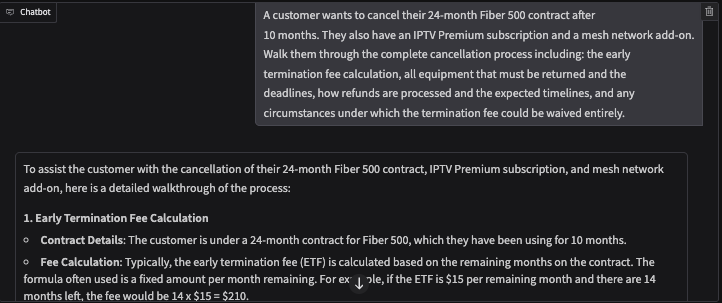

The metadata filter only detected procedures and missed policies which is where
the actual refund and cancellation rules are stored. This is a clear limitation
of the metadata filtering step because the question is heavily about policies
not just procedures.

Because of this the response had to fill in some gaps with generic estimates
rather than actual knowledge base values. For example the early termination fee
was calculated using a hypothetical $15 per remaining month figure instead of
the actual fee amount from the cancellation policy document. The phrase
"typically" and "for example" appearing multiple times in the response confirms
the RAG was guessing rather than retrieving.

The equipment return section and refund timeline were reasonable but again used
generic estimates like 4 to 6 weeks rather than the specific timelines from
our actual policy document.

The fee waiver circumstances were listed but were generic rather than specific
to our knowledge base.

This prompt reveals that when the metadata filter misclassifies a query the
entire pipeline suffers because it starts with the wrong documents. A future
improvement would be to always include policies as a default category for any
cancellation or billing related question.


In [21]:
prompt_5 = """A family of 6 living in a large villa wants a comprehensive telecom
solution. They need: home internet suitable for 4K streaming on multiple devices
simultaneously, a family mobile plan with at least 5 lines, entertainment services
including sports and children's content, smart home security monitoring, and
reliable Wi-Fi coverage across their 300 square meter property. Provide a complete
itemized recommendation with monthly costs for each component, calculate the total
monthly cost, and explain what contract term would give them the best overall value."""

response_5 = chain.invoke(prompt_5)
print(response_5)

Detected categories: ['products']
For a family of 6 living in a large villa with the specified needs, here is a comprehensive telecom solution tailored to meet all requirements:

### Home Internet
- **Fiber 500 Package**: This package offers 500 Mbps symmetric download and upload speeds, ideal for multiple 4K streams, gaming, smart home management, and extensive work from home needs.
  - **Monthly Price**: 85 OMR

### Family Mobile Plan
- **Family Unlimited**: This plan supports up to 8 lines, providing unlimited data, voice, and SMS, which is perfect for a large family. It includes premium streaming services and shared international minutes.
  - **Monthly Price**: 150 OMR

### Entertainment Services
- **Complete Family Entertainment**: Includes TV Family package, Streaming Premium, and Music Family. This bundle offers a 30% discount compared to individual services and covers sports and children's content.
  - **Monthly Price**: 65 OMR

### Smart Home Security Monitoring
- **Smart Home

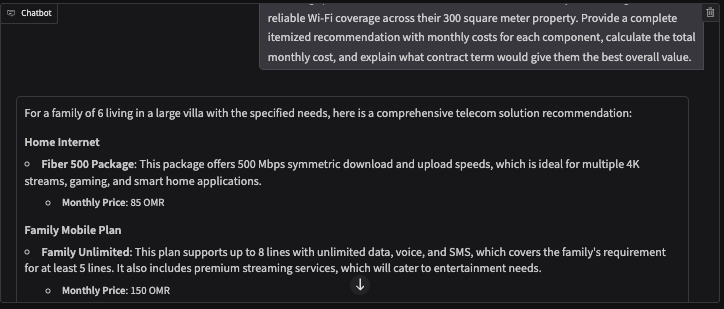

The metadata filter correctly identified products as the relevant category since
all five requirements are product related. However detecting only one category
meant the search was still across all 22 documents within that folder which is
a large pool.

The response handled the core products well. The Fiber 500 recommendation at
85 OMR, the Family Unlimited mobile plan at 150 OMR and the Complete Family
Entertainment bundle at 65 OMR were all pulled accurately from the knowledge
base with correct prices.

However the smart home security monitoring and mesh network prices were estimated
rather than retrieved. The response itself admitted this by saying "estimated,
as specific pricing is not listed in the provided context." This means those
chunks either did not get retrieved or the pricing information does not exist
in the knowledge base at that level of detail.

The total calculation of 340 OMR was performed correctly based on the numbers
it had but since two components were estimated the total is not fully accurate.

This prompt reveals the main limitation of our system. When a query spans nearly
all documents simultaneously the top 5 parent chunks passed to the LLM cannot
cover every single product category in enough detail. Some information
inevitably gets missed or estimated.

In [22]:
prompt_6 = """A medium-sized retail business with 5 store locations wants to set
up their entire telecom infrastructure from scratch. They need: dedicated internet
at each location with guaranteed uptime, a mobile fleet plan for 30 delivery
drivers with vehicle tracking, a VoIP phone system across all locations, POS
connectivity at every store, email security for 50 employees, cloud backup for
business data, and a site-to-site VPN connecting all locations. For each need,
recommend the specific product or plan, state the per-unit and total monthly cost,
identify the applicable SLA tier with its response time guarantees, and calculate
the grand total monthly expenditure across all locations and services."""

response_6 = chain.invoke(prompt_6)
print(response_6)

Detected categories: ['products']
To set up a comprehensive telecom infrastructure for a medium-sized retail business with 5 store locations, here's a detailed breakdown of the required services, costs, and SLAs:

### Dedicated Internet
- **Product**: Business Fiber Pro
- **Per-Unit Cost**: 150 OMR per location
- **Total Monthly Cost for 5 Locations**: 750 OMR
- **SLA**: 99.8% uptime with service credits
- **Response Time**: 2-hour response time guarantee

### Mobile Fleet Plan for Delivery Drivers
- **Product**: Business Mobile Plans - Professional
- **Per-Unit Cost**: 40 OMR/line (minimum 3 lines)
- **Total Monthly Cost for 30 Lines**: 1200 OMR
- **SLA**: Standard mobile SLA with priority network access

### VoIP Phone System
- **Product**: Included in Business Fiber Pro
- **Total Monthly Cost**: Included in internet cost
- **SLA**: As per Business Fiber Pro

### POS Connectivity
- **Product**: Advanced Retail (includes high-speed Wi-Fi for customers, digital signage support, invento

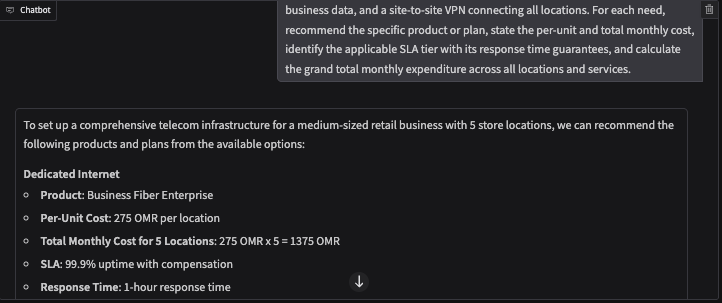

The metadata filter only detected products and missed policies which contains
the SLA tier details and response time guarantees. Because of this the SLA
information for most services was listed as "Standard SLA" rather than pulling
the specific uptime percentages and response time commitments from the actual
SLA document.

The response handled the core products reasonably well. The Business Fiber
Enterprise at 275 OMR per location, the Professional mobile plan at 40 OMR
per line and the POS connectivity at 150 OMR per location were retrieved with
specific prices and correctly multiplied across 5 locations and 30 lines.

However cloud backup pricing was estimated rather than retrieved, the response
admitted this by saying "assuming a typical cloud backup service." This is the
same limitation we saw in Prompt 5 where some product details are simply not
covered in enough depth in the retrieved chunks.

The grand total calculation was partially correct but excluded VoIP and VPN
costs since those were bundled into other services. This means the 3825 OMR
total is incomplete.

This prompt reveals two key limitations of our system. First when a query spans
nearly every document the top 5 parent chunks cannot cover all seven requirements
in enough detail simultaneously. Second the metadata filter consistently misses
policies for business related queries which means SLA details are never retrieved
with full precision. A future improvement would be to always include policies
alongside products for any business infrastructure query.

### **Complete RAG Workflow**
```
USER QUERY
     |
     ├─────────────────────────┐
     ▼                         ▼
STEP 1:                    STEP 2:
METADATA FILTER            QUERY EXPANSION
LLM classifies query       LLM generates 3 alternative
into relevant folders      phrasings → 4 queries total
     │                         │
     └─────────────┬───────────┘
                   ▼
          STEP 3: FILTERED SEARCH
          ChromaDB searches only
          relevant folder chunks
          4 queries × top 10 = 40
          candidates, deduplicated
                   │
                   ▼
          STEP 4: COHERE RERANK
          Scores all candidates
          for true relevance
          Returns top 5 only
                   │
                   ▼
          STEP 5: PARENT SWAP
          Each child chunk replaced
          by its 2000 char parent
                   │
                   ▼
          STEP 6: LLM GENERATES
          gpt-4-turbo reads query
          and parent chunks and
          produces final answer
                   │
                   ▼
            FINAL ANSWER
```

### **Overall Reflection - Strengths and Limitations of the System**

**Strengths**

The system performed best on medium difficulty prompts like Prompt 1 and Prompt
2 where the question mapped cleanly to one or two documents. The metadata filter
routed correctly, query expansion helped with vocabulary mismatches and the
parent chunks gave the LLM enough context for complete and specific answers.
For example Prompt 2 returned all four postpaid plans with correct prices and
a well reasoned recommendation which shows the pipeline working exactly as
intended.

Parent child chunking made a noticeable difference on Prompt 3 where the LLM
needed to answer four sub questions simultaneously. Because it received full
2000 character parent chunks it had enough surrounding context to cover all
four parts without missing any, which would not have been possible with smaller
1000 character chunks alone.

**Limitations**

The metadata filter was the weakest link in the pipeline. In Prompt 4 it only
detected procedures and missed policies which is where the actual cancellation
and refund rules live. This caused the response to use estimated figures instead
of real values from the knowledge base. In Prompts 5 and 6 it only detected
products and missed policies which meant SLA details were never retrieved with
full precision.

The very hard prompts revealed a second limitation which is that the top 5
parent chunks passed to the LLM cannot cover every document simultaneously
when a query spans the entire knowledge base. Some pricing information was
estimated rather than retrieved in both Prompt 5 and Prompt 6 because the
relevant chunks simply did not make it into the final top 5.

**Future Improvements**

The metadata filter could be improved by always including policies as a default
category for any billing, cancellation or business related query rather than
relying entirely on the LLM to detect it. Increasing top_n in the reranker
from 5 to 8 or 10 would also help the very hard prompts by giving the LLM more
documents to work with for complex multi part questions.